## Relationship Model Build


In [ ]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

import torch
from torch.utils.data import Dataset, DataLoader

from PIL import Image

from datasets.visual_genome import VisualGenomeLoader
from models.relationship import RelationshipDataset
from models.relationship import build_transforms

In [2]:
loader = VisualGenomeLoader(
    "../datasets/visual_genome"
)

In [3]:
identity = lambda x: x
dataset = RelationshipDataset(
    loader,
    image_indices=[0],
    transform=identity
)

sample = dataset[0]

for key, value in sample.items():
    print(key)

    if isinstance(value, torch.Tensor):
        print(value.shape, value.dtype)
    else:
        print(type(value))
print(len(dataset))

image_index
<class 'int'>
image
<class 'PIL.Image.Image'>
subject_label
torch.Size([]) torch.int64
object_label
torch.Size([]) torch.int64
subject_bbox
torch.Size([4]) torch.float32
object_bbox
torch.Size([4]) torch.float32
target
torch.Size([]) torch.int64
50


Sample: 45
Target: 51


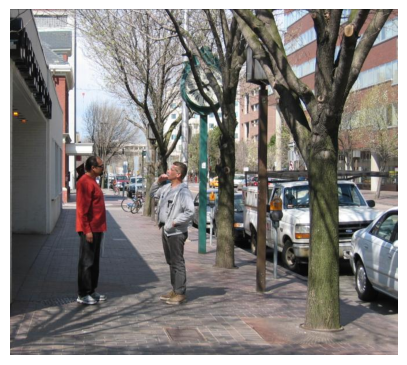

Sample: 40
Target: 51


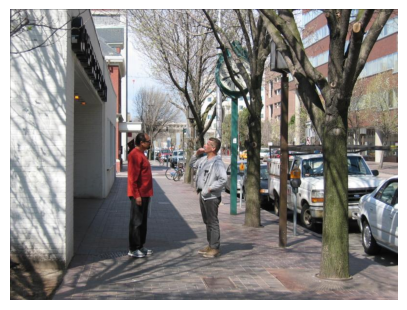

Sample: 27
Target: 51


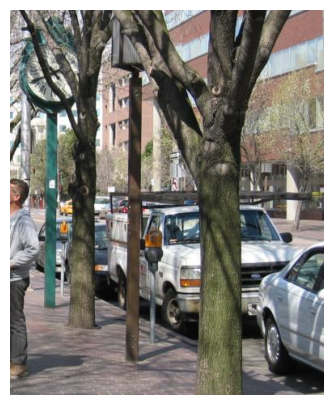

Sample: 2
Target: 20


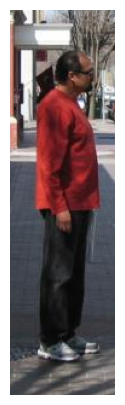

Sample: 12
Target: 30


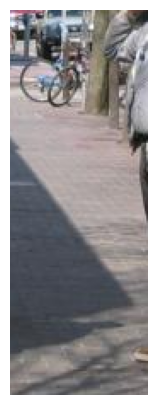

In [4]:
import random
import matplotlib.pyplot as plt

for _ in range(5):

    idx = random.randint(0, len(dataset)-1)

    sample = dataset[idx]

    print("="*60)
    print("Sample:", idx)
    print("Target:", sample["target"].item())

    plt.figure(figsize=(5,5))
    plt.imshow(sample["image"])
    plt.axis("off")
    plt.show()

In [5]:
for i in range(len(dataset)):
    _ = dataset[i]

print("RelationshipDataset passed.")

RelationshipDataset passed.


## Pytorch Data generation done

In [9]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

import torch
from torch.utils.data import Dataset, DataLoader

from PIL import Image

from datasets.visual_genome import VisualGenomeLoader
from models.relationship import RelationshipDataset
loader = VisualGenomeLoader(
    "../datasets/visual_genome"
)
from models.relationship import build_transforms

##### Converted to tensor (input to nn) except (unioin image)

In [11]:
from models.relationship.encoder import ImageEncoder

encoder = ImageEncoder()
print(encoder)

ImageEncoder(
  (model): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
      (patch_dropout): Identity()
      (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (transformer): Transformer(
        (resblocks): ModuleList(
          (0-11): 12 x ResidualAttentionBlock(
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
            )
            (ls_1): Identity()
            (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=768, out_features=3072, bias=True)
              (gelu): GELU(approximate='none')
              (c_proj): Linear(in_features=3072, out_features=768, bias=True)
            )
            (ls_2): I

In [12]:
train_transform, val_transform = build_transforms(
    encoder.preprocess
)

print(train_transform)

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeConvertMode()
    MaybeToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


In [13]:
dataset = RelationshipDataset(
    loader,
    image_indices=[0],
    transform=train_transform,
)

In [15]:
sample = dataset[0]
for key, value in sample.items():

    print("-" * 50)
    print(key)

    if isinstance(value, torch.Tensor):
        print(value.shape)
        print(value.dtype)

    else:
        print(type(value))

--------------------------------------------------
image_index
<class 'int'>
--------------------------------------------------
image
torch.Size([3, 224, 224])
torch.float32
--------------------------------------------------
subject_label
torch.Size([])
torch.int64
--------------------------------------------------
object_label
torch.Size([])
torch.int64
--------------------------------------------------
subject_bbox
torch.Size([4])
torch.float32
--------------------------------------------------
object_bbox
torch.Size([4])
torch.float32
--------------------------------------------------
target
torch.Size([])
torch.int64


In [16]:
print(sample["image"].min())
print(sample["image"].max())

tensor(-1.7923)
tensor(2.1459)


In [17]:
image = sample["image"].unsqueeze(0)

print(image.shape)

torch.Size([1, 3, 224, 224])


In [18]:
with torch.no_grad():

    features = encoder(image)

print(features.shape)

torch.Size([1, 512])


In [19]:
print(features)

tensor([[ 9.7241e-02,  3.9111e-01,  1.5064e-01, -2.4511e-01,  1.0457e-01,
         -3.3460e-01, -4.1155e-01, -2.5670e-01,  5.2511e-02, -1.1654e-01,
          2.7445e-01,  1.2377e-01,  5.1398e-02,  2.2316e-01, -1.7006e-02,
          1.0678e-01,  9.7192e-01,  2.2565e-01,  3.3768e-01, -2.8929e-01,
          2.9208e-01,  6.8833e-02, -1.3399e-01,  1.3818e-01, -5.4761e-01,
          2.2697e-01,  4.2630e-01,  3.1325e-01,  1.9620e-01,  3.3856e-02,
         -4.6685e-01,  1.9748e-01,  4.7051e-01,  4.9874e-01,  3.8584e-01,
          4.3726e-01, -7.6364e-02,  3.0083e-01, -6.6867e-01,  2.8692e-01,
          2.4494e-01, -8.2994e-02,  6.0181e-02,  1.7444e-01, -3.0016e-01,
          1.6782e+00,  4.6489e-01,  3.7802e-01, -4.3360e-01,  1.6224e-01,
          6.4587e-01,  1.8096e-01,  1.3983e-01, -4.4971e-01,  4.3970e-02,
         -3.3544e-02,  2.5360e-01, -2.6801e-01,  1.3289e-01,  2.1615e-01,
          5.1986e-01,  2.6329e-01,  5.1136e-02,  6.3890e-02,  1.9870e-01,
         -9.2578e-02,  1.3436e-01,  1.

#### Concatenated, img data, objects data everything into numeric

In [1]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

import torch
from torch.utils.data import Dataset, DataLoader

from PIL import Image

from datasets.visual_genome import VisualGenomeLoader
from models.relationship import (RelationshipDataset,ImageEncoder,
    RelationshipModel,
    build_transforms,)
loader = VisualGenomeLoader(
    "../datasets/visual_genome"
)


c:\Users\psytr\Desktop\Projects\scene_graph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
encoder = ImageEncoder()
train_transform, _ = build_transforms(
    encoder.preprocess
)

In [4]:
dataset = RelationshipDataset(
    loader,
    image_indices=[0],
    transform=train_transform,
)

In [5]:
sample = dataset[0]

In [6]:
model = RelationshipModel(
    encoder=encoder,
    num_object_classes=150,
    num_predicate_classes=51,
)

In [7]:
image = sample["image"].unsqueeze(0)

subject_label = sample["subject_label"].unsqueeze(0)

object_label = sample["object_label"].unsqueeze(0)

subject_bbox = sample["subject_bbox"].unsqueeze(0)

object_bbox = sample["object_bbox"].unsqueeze(0)

In [9]:
logits = model(

    image,

    subject_label,

    object_label,

    subject_bbox,

    object_bbox,

)

In [10]:
print(logits.shape)

torch.Size([1, 51])


In [11]:
prediction = logits.argmax(dim=1)

print(prediction)

tensor([30])


In [12]:
probabilities = torch.softmax(
    logits,
    dim=1
)

print(probabilities.sum())

tensor(1., grad_fn=<SumBackward0>)


### Created .py file module completely for relationship model